## University Of Engineering And Technology Peshawar Nowshera Campus
#### Sohaib ur Rehman Farooqi
#### Reg No 22JZELE0458

# Objective
#### The objective of this lab is to develop a machine learning model capable of forecasting future electricity demand using the CityLearn dataset. Accurate forecasting helps optimize energy management, demand response, and smart grid operations.

## Import Libraries

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

## Load Dataset

In [17]:
# path to your building_3.csv
data = pd.read_csv(r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\Building_2.csv')
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (720, 16)


,month,hour,day_type,daylight_savings_status,indoor_dry_bulb_temperature,average_unmet_cooling_setpoint_difference,indoor_relative_humidity,non_shiftable_load,dhw_demand,cooling_demand,heating_demand,solar_generation,occupant_count,indoor_dry_bulb_temperature_cooling_set_point,indoor_dry_bulb_temperature_heating_set_point,hvac_mode
0,6,1,5,0,24.278513,-0.165932,60.703620,0.187333,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1
1,6,2,5,0,24.264734,-0.179711,61.140690,0.185918,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1
2,6,3,5,0,24.214113,-0.230331,61.779377,0.184616,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1
3,6,4,5,0,24.119434,-0.325011,62.557430,0.187352,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1
4,6,5,5,0,23.995500,-0.448944,64.078804,0.202237,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1


##  Missing Values

In [18]:
#  MISSING VALUE HANDLING
print("Missing Values Before Cleaning:\n")
data.isnull().sum()

Missing Values Before Cleaning:



month                                            0
hour                                             0
day_type                                         0
daylight_savings_status                          0
indoor_dry_bulb_temperature                      0
average_unmet_cooling_setpoint_difference        0
indoor_relative_humidity                         0
non_shiftable_load                               0
dhw_demand                                       0
cooling_demand                                   0
heating_demand                                   0
solar_generation                                 0
occupant_count                                   0
indoor_dry_bulb_temperature_cooling_set_point    0
indoor_dry_bulb_temperature_heating_set_point    0
hvac_mode                                        0
dtype: int64

## Data Cleaning 

In [19]:
data.fillna(method='ffill', inplace=True)
# If still any NaN, fill with 0
data.fillna(0, inplace=True)
print("\nMissing Values After Cleaning:\n")
print(data.isnull().sum())
print("\nDataset Shape After Cleaning:", data.shape)


Missing Values After Cleaning:

month                                            0
hour                                             0
day_type                                         0
daylight_savings_status                          0
indoor_dry_bulb_temperature                      0
average_unmet_cooling_setpoint_difference        0
indoor_relative_humidity                         0
non_shiftable_load                               0
dhw_demand                                       0
cooling_demand                                   0
heating_demand                                   0
solar_generation                                 0
occupant_count                                   0
indoor_dry_bulb_temperature_cooling_set_point    0
indoor_dry_bulb_temperature_heating_set_point    0
hvac_mode                                        0
dtype: int64

Dataset Shape After Cleaning: (720, 16)


## Data Exploration

In [20]:
print("\nBasic Statistics:")
print(data['solar_generation'].describe())


Basic Statistics:
count    720.000000
mean     200.066115
std      243.372592
min        0.000000
25%        0.000000
50%       35.825709
75%      422.030280
max      703.628300
Name: solar_generation, dtype: float64


## Feature Selection

In [21]:
print("Final Dataset Shape:", data.shape)
data.head()

Final Dataset Shape: (720, 16)


,month,hour,day_type,daylight_savings_status,indoor_dry_bulb_temperature,average_unmet_cooling_setpoint_difference,indoor_relative_humidity,non_shiftable_load,dhw_demand,cooling_demand,heating_demand,solar_generation,occupant_count,indoor_dry_bulb_temperature_cooling_set_point,indoor_dry_bulb_temperature_heating_set_point,hvac_mode
0,6,1,5,0,24.278513,-0.165932,60.703620,0.187333,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1
1,6,2,5,0,24.264734,-0.179711,61.140690,0.185918,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1
2,6,3,5,0,24.214113,-0.230331,61.779377,0.184616,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1
3,6,4,5,0,24.119434,-0.325011,62.557430,0.187352,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1
4,6,5,5,0,23.995500,-0.448944,64.078804,0.202237,0.0,0.0,0.0,0.0,1.0,24.444445,24.444445,1


## Min-Max Scaling

In [22]:
from sklearn.preprocessing import MinMaxScaler
import pickle
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
# Save scaler
pickle.dump(scaler, open("CityLearn_scaler.pkl", "wb"))
print("Scaled Data Shape:", scaled_data.shape)
print("\nFirst 5 rows of scaled data:\n")
print(scaled_data[:5])

Scaled Data Shape: (720, 16)

First 5 rows of scaled data:

[[0.         0.         0.66666667 0.         0.67209014 0.73386063
  0.40554198 0.00215442 0.         0.         0.         0.
  1.         0.71428601 0.71428601 0.        ]
 [0.         0.04347826 0.66666667 0.         0.66853275 0.72605209
  0.42047205 0.00199095 0.         0.         0.         0.
  1.         0.71428601 0.71428601 0.        ]
 [0.         0.08695652 0.66666667 0.         0.6554637  0.69736629
  0.44228926 0.00184057 0.         0.         0.         0.
  1.         0.71428601 0.71428601 0.        ]
 [0.         0.13043478 0.66666667 0.         0.63101999 0.64371188
  0.46886713 0.00215658 0.         0.         0.         0.
  1.         0.71428601 0.71428601 0.        ]
 [0.         0.17391304 0.66666667 0.         0.59902338 0.57347992
  0.52083645 0.00387612 0.         0.         0.         0.
  1.         0.71428601 0.71428601 0.        ]]


## Sequance Data Shape

In [23]:
time_steps = 24
num_features = scaled_data.shape[1]

X = []
y = []

# Get index of target column
target_col = data.columns.get_loc("solar_generation")

for i in range(time_steps, len(scaled_data)):
    X.append(scaled_data[i-time_steps:i])
    y.append(scaled_data[i, target_col])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)


X Shape: (696, 24, 16)


## Train, Test And Validation

In [24]:
# (Train: 70% , Test : 20% and valadiation : 10%)
train_size = int(0.7 * len(X))
val_size   = int(0.2 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

Train Shape: (487, 24, 16)
Validation Shape: (139, 24, 16)
Test Shape: (70, 24, 16)


## BiLSTM Model

In [25]:
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(time_steps, X_train.shape[2])),
    Dropout(0.2),

    Bidirectional(LSTM(32)),
    Dropout(0.2),

    Dense(1)
])

## Model Compile 

In [28]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

## Model Traning 

In [29]:
epochs = 100

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=32,
    verbose=1
)

Epoch 1/100
16/16 [==============================] - 31s 386ms/step - loss: 0.1032 - mae: 0.2569 - val_loss: 0.0448 - val_mae: 0.1894
Epoch 2/100
16/16 [==============================] - 1s 74ms/step - loss: 0.0337 - mae: 0.1520 - val_loss: 0.0208 - val_mae: 0.1231
Epoch 3/100
16/16 [==============================] - 1s 88ms/step - loss: 0.0252 - mae: 0.1303 - val_loss: 0.0178 - val_mae: 0.1093
Epoch 4/100
16/16 [==============================] - 1s 80ms/step - loss: 0.0221 - mae: 0.1194 - val_loss: 0.0150 - val_mae: 0.0988
Epoch 5/100
16/16 [==============================] - 1s 73ms/step - loss: 0.0169 - mae: 0.1029 - val_loss: 0.0123 - val_mae: 0.0903
Epoch 6/100
16/16 [==============================] - 1s 80ms/step - loss: 0.0165 - mae: 0.1023 - val_loss: 0.0142 - val_mae: 0.0882
Epoch 7/100
16/16 [==============================] - 1s 78ms/step - loss: 0.0138 - mae: 0.0916 - val_loss: 0.0084 - val_mae: 0.0743
Epoch 8/100
16/16 [==============================] - 1s 80ms/step - loss: 

## Predaction 

In [30]:
y_pred = model.predict(X_test)
print("Prediction Shape:", y_pred.shape)
print("Test Shape:", y_test.shape)

3/3 [==============================] - 7s 20ms/step
Prediction Shape: (70, 1)
Test Shape: (70,)


## Model Evaluation

In [31]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.02671102353419862
RMSE: 0.03643062164106502
R2  : 0.9901517277666557


## Actual & Predaction Graph

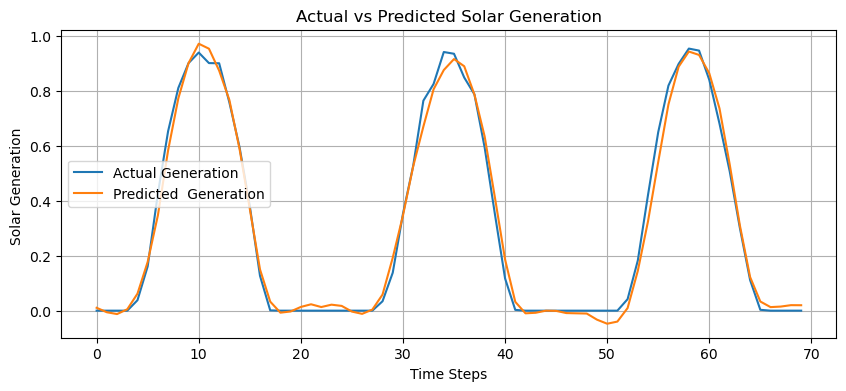

In [33]:

# Plot Results
plt.figure(figsize=(10,4))
plt.plot(y_test[:1000], label='Actual Generation')
plt.plot(y_pred[:1000], label='Predicted  Generation')
plt.title('Actual vs Predicted Solar Generation')
plt.xlabel('Time Steps')
plt.ylabel('Solar Generation ')
plt.legend()
plt.grid(True)
plt.show()


## Actual And Predection Comparison

In [34]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("Actual Std   :", y_test.std())
print("Predicted Std:", y_pred.std())

3/3 [==============================] - 0s 24ms/step
MAE : 0.02671102353419862
RMSE: 0.03643062164106502
R2  : 0.9901517277666557
Actual Std   : 0.3671018383836584
Predicted Std: 0.36098048


## Conclusion 


The model demonstrated strong predictive performance on the test set:

* MAE : 0.02671102353419862
* RMSE: 0.03643062164106502
* R2  : 0.9901517277666557
* Actual Std   : 0.3671018383836584
* Predicted Std: 0.36098048



